<img src="https://gitlab.com/bivl2ab/academico/cursos-uis/ai/ai-uis-student/raw/master/imgs/speech.jpeg" alt="Drawing" style="width:1700px;">



# <center> 11. Complement lecture on Deep neuronal networks </center>


### Additional applications

From DNN lecture seen on previous class, try to approach this algorithms in other application: audio recognition

In [1]:
import tensorflow as tf
from tensorflow import keras

import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## <span style="color:green"> If you are in colaboratoy </span>: 

In [2]:
from google.colab import drive
drive.mount('/content/drive')
%cd drive/My Drive/ai-uis-student/notebooks
!pwd

Go to this URL in a browser: https://accounts.google.com/o/oauth2/auth?client_id=947318989803-6bn6qk8qdgf4n4g3pfee6491hc0brc4i.apps.googleusercontent.com&redirect_uri=urn%3aietf%3awg%3aoauth%3a2.0%3aoob&response_type=code&scope=email%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdocs.test%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdrive%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdrive.photos.readonly%20https%3a%2f%2fwww.googleapis.com%2fauth%2fpeopleapi.readonly

Enter your authorization code:
··········
Mounted at /content/drive
/content/drive/My Drive/ai-uis-student/notebooks
/content/drive/My Drive/ai-uis-student/notebooks


A typical library to read and rpocess audio is `librosa`. We firstly install library and then we can start to work. 

In [0]:
!pip install librosa

# 1. Free Spoken Digit Dataset (FSDD)
## The speech MNIST

A simple audio/speech dataset consisting of recordings of spoken digits in wav files at 8kHz. The recordings are trimmed so that they have near minimal silence at the beginnings and ends [Source](https://github.com/Jakobovski/free-spoken-digit-dataset)

### Dataset description

- 4 speakers
- 2.000 recordings (50 of each digit per speaker)
- English pronunciations

An example of the dataset: `{digitLabel}_{speakerName}_{index}.wav` Example: `7_jackson_32.wav`

sr: 8000
wav shape: (3532,)


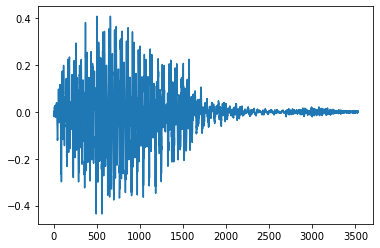

In [3]:
import librosa
wav, sr = librosa.load('../data/fsdd/8_jackson_40.wav', sr=None)
print( 'sr:', sr)
print( 'wav shape:', wav.shape)

plt.plot(wav);

more specifically..

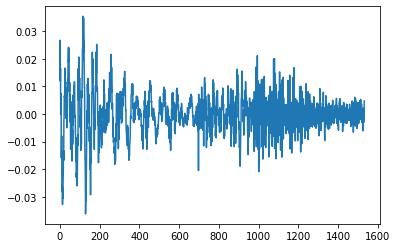

In [4]:
plt.plot(wav[2000:5000])

## <span style="color:orange">Student Challenge </span>: 
- Read the FSDD audio dataset, using `librosa` library
  - Built the $\mathbf{X}$ $\in$ $\mathbb{R}^{n \times m}$ matrix. The $n$ rows are the examples (20000) and $m$ colums is the dimension of each file. 
  - Built the $\mathbf{y} \in \mathbb{R}^{n}$ corresponding to classes labels. 
    
    
** Pay attention that all files dont have the same dimension. Then, we add zeros to obtain files with same size. This process is named `padding`    
- For so, you can use next function. 

In [0]:
def func_padding(wav, pad_size=10000):
    if wav.shape[0] > pad_size:
        return wav[0: pad_size]
    else:
        return np.hstack((wav, np.zeros(pad_size - wav.shape[0])))

In [0]:

def get_XyData(DATA_DIR = '../data/fsdd/', pad_size=10000):

  X =[]
  y =[]
  
  for fname in os.listdir(DATA_DIR):
    struct = fname.split('_')
    digit = struct[0]
    wav, sr = librosa.load(DATA_DIR + fname)
    padded = func_padding(wav, pad_size)
    X.append(padded)
    y.append(digit)   
  return np.vstack(X), np.array(y)

In [7]:
X, y = get_XyData(DATA_DIR = '../data/fsdd/')
print( 'X:', X.shape)
print( 'y:', y.shape)

X: (2000, 10000)
y: (2000,)


## <span style="color:orange">Student Challenge </span>:
- Split data on training (90% ) and test (10%).

In [0]:
from sklearn.model_selection import train_test_split
test_size = 0.1
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size)



## <span style="color:orange">Student Challenge </span>:
- Built a DNN with the following configuration: 
    - the input is the `x[0]` dimension
    - A hidden layer of 128 neurons. 
    - the output is `softmax` layer with `10` outputs, corresponding to classes
    - print the summary

In [10]:
model = keras.models.Sequential([
    keras.layers.Flatten( input_shape= (X[0].shape)),
    keras.layers.Dense(128, activation=tf.nn.relu),                             
    keras.layers.Dense(10, activation=tf.nn.softmax)                    
])



model.summary()

Instructions for updating:
If using Keras pass *_constraint arguments to layers.
Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten (Flatten)            (None, 10000)             0         
_________________________________________________________________
dense (Dense)                (None, 128)               1280128   
_________________________________________________________________
dense_1 (Dense)              (None, 10)                1290      
Total params: 1,281,418
Trainable params: 1,281,418
Non-trainable params: 0
_________________________________________________________________


In [0]:
model.compile(optimizer=tf.train.AdamOptimizer(), 
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

fit the model wit a  `batch_size=10` and `epochs=15`

In [12]:

model.fit(X_train, y_train, batch_size=10, epochs=15)



Train on 1800 samples
Epoch 1/15
1800/1800 [==============================] - 2s 1ms/sample - loss: 2.3315 - acc: 0.1606
Epoch 2/15
1800/1800 [==============================] - 0s 274us/sample - loss: 1.7288 - acc: 0.4589
Epoch 3/15
1800/1800 [==============================] - 0s 258us/sample - loss: 1.4202 - acc: 0.5817
Epoch 4/15
1800/1800 [==============================] - 0s 248us/sample - loss: 1.2154 - acc: 0.6722
Epoch 5/15
1800/1800 [==============================] - 0s 249us/sample - loss: 1.0716 - acc: 0.7317
Epoch 6/15
1800/1800 [==============================] - 0s 249us/sample - loss: 0.9506 - acc: 0.7817
Epoch 7/15
1800/1800 [==============================] - 0s 251us/sample - loss: 0.8382 - acc: 0.8156
Epoch 8/15
1800/1800 [==============================] - 0s 255us/sample - loss: 0.7321 - acc: 0.8594
Epoch 9/15
1800/1800 [==============================] - 0s 250us/sample - loss: 0.6272 - acc: 0.8844
Epoch 10/15
1800/1800 [==============================] - 0s 251us/sampl

In [14]:
test_loss, test_acc = model.evaluate(X_test, y_test)

print( 'Test accuracy:', test_acc, " test_loss: ", test_loss)

200/200 [==============================] - 0s 209us/sample - loss: 6.9524 - acc: 0.2000
Test accuracy: 0.2  test_loss:  6.952354850769043


Compile the model, using the next configuration

Train on 1800 samples, validate on 200 samples
Epoch 1/10
1800/1800 [==============================] - 0s 106us/sample - loss: 0.3106 - acc: 0.9611 - val_loss: 6.9692 - val_acc: 0.2050
Epoch 2/10
1800/1800 [==============================] - 0s 93us/sample - loss: 0.3004 - acc: 0.9644 - val_loss: 7.0131 - val_acc: 0.1950
Epoch 3/10
1800/1800 [==============================] - 0s 95us/sample - loss: 0.2914 - acc: 0.9672 - val_loss: 7.0651 - val_acc: 0.2000
Epoch 4/10
1800/1800 [==============================] - 0s 95us/sample - loss: 0.2833 - acc: 0.9689 - val_loss: 7.1242 - val_acc: 0.2000
Epoch 5/10
1800/1800 [==============================] - 0s 95us/sample - loss: 0.2754 - acc: 0.9711 - val_loss: 7.1660 - val_acc: 0.2000
Epoch 6/10
1800/1800 [==============================] - 0s 96us/sample - loss: 0.2680 - acc: 0.9711 - val_loss: 7.2252 - val_acc: 0.2050
Epoch 7/10
1800/1800 [==============================] - 0s 102us/sample - loss: 0.2607 - acc: 0.9722 - val_loss: 7.2852 - val_acc:

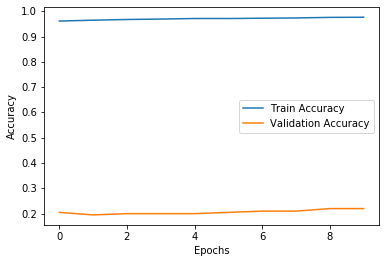

In [15]:
history = model.fit(X_train,
          y_train,
          epochs=10,
          batch_size=40,
          validation_data=(X_test, y_test))

plt.plot(history.history['acc'], label='Train Accuracy')
plt.plot(history.history['val_acc'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

## <span style="color:orange">Student Challenge </span>:
- what happened? ...
- Try with other DNN network more conected:
    - hidden layer of 10000
- Try with other DNN network **more deeply**:    
    - hidden layer of 1500
    - hidden layer of 500
    - hidden layer of 1500
- Try also changing padding parameter to obtaine samples with size: [5000, 20000]


In [18]:
model = keras.models.Sequential([
    keras.layers.Flatten( input_shape= (X_train[0].shape)),
    keras.layers.Dense(5000, activation=tf.nn.relu),
    keras.layers.Dense(2500, activation=tf.nn.relu),
    keras.layers.Dense(1500, activation=tf.nn.relu),
    keras.layers.Dense(500, activation=tf.nn.relu),
    keras.layers.Dense(256, activation=tf.nn.relu),
    keras.layers.Dense(128, activation=tf.nn.relu),
    keras.layers.Dense(10, activation=tf.nn.softmax)
])
model.summary()

Model: "sequential_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten_2 (Flatten)          (None, 10000)             0         
_________________________________________________________________
dense_6 (Dense)              (None, 5000)              50005000  
_________________________________________________________________
dense_7 (Dense)              (None, 2500)              12502500  
_________________________________________________________________
dense_8 (Dense)              (None, 1500)              3751500   
_________________________________________________________________
dense_9 (Dense)              (None, 500)               750500    
_________________________________________________________________
dense_10 (Dense)             (None, 256)               128256    
_________________________________________________________________
dense_11 (Dense)             (None, 128)              

Train on 1800 samples, validate on 200 samples
Epoch 1/40
1800/1800 [==============================] - 1s 289us/sample - loss: 2.3136 - acc: 0.0944 - val_loss: 2.3068 - val_acc: 0.1150
Epoch 2/40
1800/1800 [==============================] - 0s 195us/sample - loss: 2.1973 - acc: 0.1989 - val_loss: 2.2953 - val_acc: 0.1850
Epoch 3/40
1800/1800 [==============================] - 0s 196us/sample - loss: 1.9218 - acc: 0.3144 - val_loss: 2.3771 - val_acc: 0.1900
Epoch 4/40
1800/1800 [==============================] - 0s 199us/sample - loss: 1.6074 - acc: 0.4678 - val_loss: 2.7687 - val_acc: 0.2650
Epoch 5/40
1800/1800 [==============================] - 0s 193us/sample - loss: 1.3202 - acc: 0.5628 - val_loss: 2.9817 - val_acc: 0.2050
Epoch 6/40
1800/1800 [==============================] - 0s 196us/sample - loss: 1.0983 - acc: 0.6467 - val_loss: 3.6511 - val_acc: 0.2050
Epoch 7/40
1800/1800 [==============================] - 0s 200us/sample - loss: 0.8437 - acc: 0.7411 - val_loss: 4.7031 - val

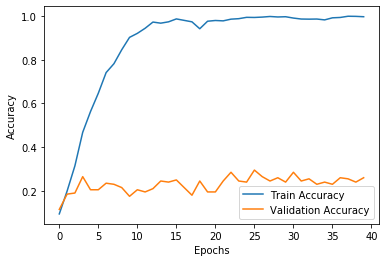

In [19]:
model.compile(optimizer=tf.train.AdamOptimizer(), 
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
history = model.fit(X_train,
          y_train,
          epochs=40,
          batch_size=100,
          validation_data=(X_test, y_test))

plt.plot(history.history['acc'], label='Train Accuracy')
plt.plot(history.history['val_acc'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

## <span style="color:orange">Student Challenge </span>:

- Raw signals are not good candidate to represent audio. So, we can compute a natural feature of this sign that is the FFT

See an example

(1025, 7)
(7175,)


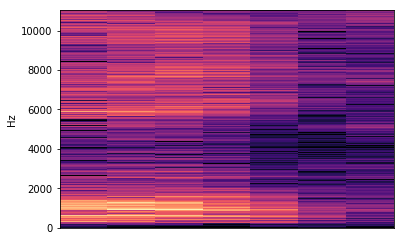

In [0]:
import librosa.display as dis
D = librosa.amplitude_to_db(np.abs(librosa.stft(wav)), ref=np.max)
print D.shape
print D.reshape(D.shape[0]*D.shape[1]).shape
dis.specshow(D, y_axis='linear');

In audio one of the more relevant and compact features is the `melspectrogram` [wiki](https://es.wikipedia.org/wiki/MFCC)

(128, 7)


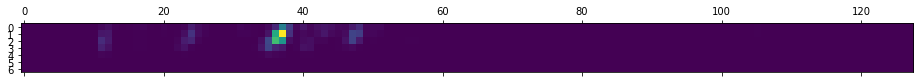

In [21]:
SP = librosa.feature.melspectrogram(wav)
print( SP.shape)
plt.matshow(SP.T)

## <span style="color:orange">Student Challenge </span>:

Built a function to recover $\mathbf{X},\mathbf{y}$ but using melspectrogram as descriptor. 
    - Do a padding of max = 1000

In [0]:
def get_Xy_Features(DATA_DIR = '../data/fsdd/', pad_size=1000):
    
    X = []
    y = []

    for fname in os.listdir(DATA_DIR):
        struct = fname.split('_')
        digit = struct[0]
        wav, sr = librosa.load(DATA_DIR + fname)
        D = librosa.feature.melspectrogram(wav)
        padded = func_padding(D.reshape(D.shape[0]*D.shape[1]), pad_size)
        #print D.reshape(D.shape[0]*D.shape[1]).shape
        #print padded.shape
        X.append(padded)        
        y.append(digit)
    return np.vstack(X), np.array(y)



In [24]:
from sklearn.model_selection import train_test_split
X, y = get_Xy_Features(DATA_DIR = '../data/fsdd/')
print( 'X:', X.shape)
print( 'y:', y.shape)
test_size = 0.1
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size)

X: (2000, 1000)
y: (2000,)


Now train a DNN model: 
    - Using an input of 1000.
    - A hidden layer of 2000 neurons
    - A hidden layer of 1000 neurons
    - A hidden layer of 500 neurons
    - A sof max layer of 10

In [0]:
model = keras.models.Sequential([

    
    
])
model.summary()

In [0]:
model.compile(optimizer=tf.train.AdamOptimizer(), 
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
history = model.fit(X_train,
          y_train,
          epochs=7,
          batch_size=300,
          validation_data=(X_test, y_test),
          verbose=False)

plt.plot(history.history['acc'], label='Train Accuracy')
plt.plot(history.history['val_acc'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

In [0]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=False)

print 'Test accuracy:', test_acc, " test_loss: ", test_loss

## <span style="color:orange">Student Challenge </span>:
- In this particular dataset, it is better to perform train-test split according to the actors, that its to say:
    - Three actors for training
    - The other actor for test. 
Built a function that receive a list with three actors for training and the actor for test and return the respectives $( \mathbf{X_{tr}}, \mathbf{X_{te}}, \mathbf{y_{tr}}, \mathbf{y_{te}} )$


In [0]:
DATA_DIR = '../data/fsdd/'
def fun_ByActor(list_train = ['jackson','theo','yweweler'], pad_size=1000):

    
    
            
                
    return np.vstack(X_tr),np.vstack(X_te), np.array(y_tr),np.array(y_te) 

In [0]:
X_tr, X_te, y_tr, y_te = fun_ByActor(['jackson','theo','yweweler'], 1000)

In [0]:
print X_tr.shape, X_te.shape, y_tr.shape, y_te.shape

(1500, 1000) (500, 1000) (1500,) (500,)


Check the previous configuration. 
 - What about the performance?

In [0]:
model = keras.models.Sequential([

    
    
    
    
])
model.summary()

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten_1 (Flatten)          (None, 1000)              0         
_________________________________________________________________
dense_1 (Dense)              (None, 2000)              2002000   
_________________________________________________________________
dense_2 (Dense)              (None, 1000)              2001000   
_________________________________________________________________
dense_3 (Dense)              (None, 500)               500500    
_________________________________________________________________
dense_4 (Dense)              (None, 10)                5010      
Total params: 4,508,510
Trainable params: 4,508,510
Non-trainable params: 0
_________________________________________________________________


In [0]:
model.compile(optimizer=tf.train.AdamOptimizer(), 
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [0]:
history = model.fit(X_tr,
          y_tr,
          epochs=10,
          batch_size=1000,
          validation_data=(X_te, y_te))

plt.plot(history.history['acc'], label='Train Accuracy')
plt.plot(history.history['val_acc'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

In [0]:
test_loss, test_acc = model.evaluate(X_te, y_te, verbose=False)

print 'Test accuracy:', test_acc, " test_loss: ", test_loss

---
<img src="../imgs/bannerThanks.jpg" style="width:1000px;">